In [121]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [122]:
pd.set_option('display.max_columns', None)
sns.set_theme(rc={
        'figure.figsize': (18, 12),
        'xtick.labelsize': 10,
    },
)

In [123]:
path = os.path.join("..", "intermediate", "out.csv")
df = pd.read_csv(path)

In [124]:
SPECIFIC_MODEL_TUPLE = ['_brand', '_model', '_generation', '_bodyType', '_engineType', '_engineCapacity', '_transmissionType']
SPECIFIC_MODELS = [
    ('Audi', 'A4'),
    ('Kia', 'K5'),
    ('Toyota', 'Camry'),
    ('Mazda', '6'),
    ('Voyah', 'Free'),
    ('Volvo', 'S60'),
    ('BMW', '3 серия'),
    ('BMW', 'X1'),
    ('Skoda', 'Octavia'),
    ('Hyundai', 'Sonata'),
]

subdf = df.copy()
subdf = subdf[subdf.set_index(SPECIFIC_MODEL_TUPLE).index.isin(SPECIFIC_MODELS)]
subdf['_specificModel'] = subdf[SPECIFIC_MODEL_TUPLE].agg(' '.join, axis=1)

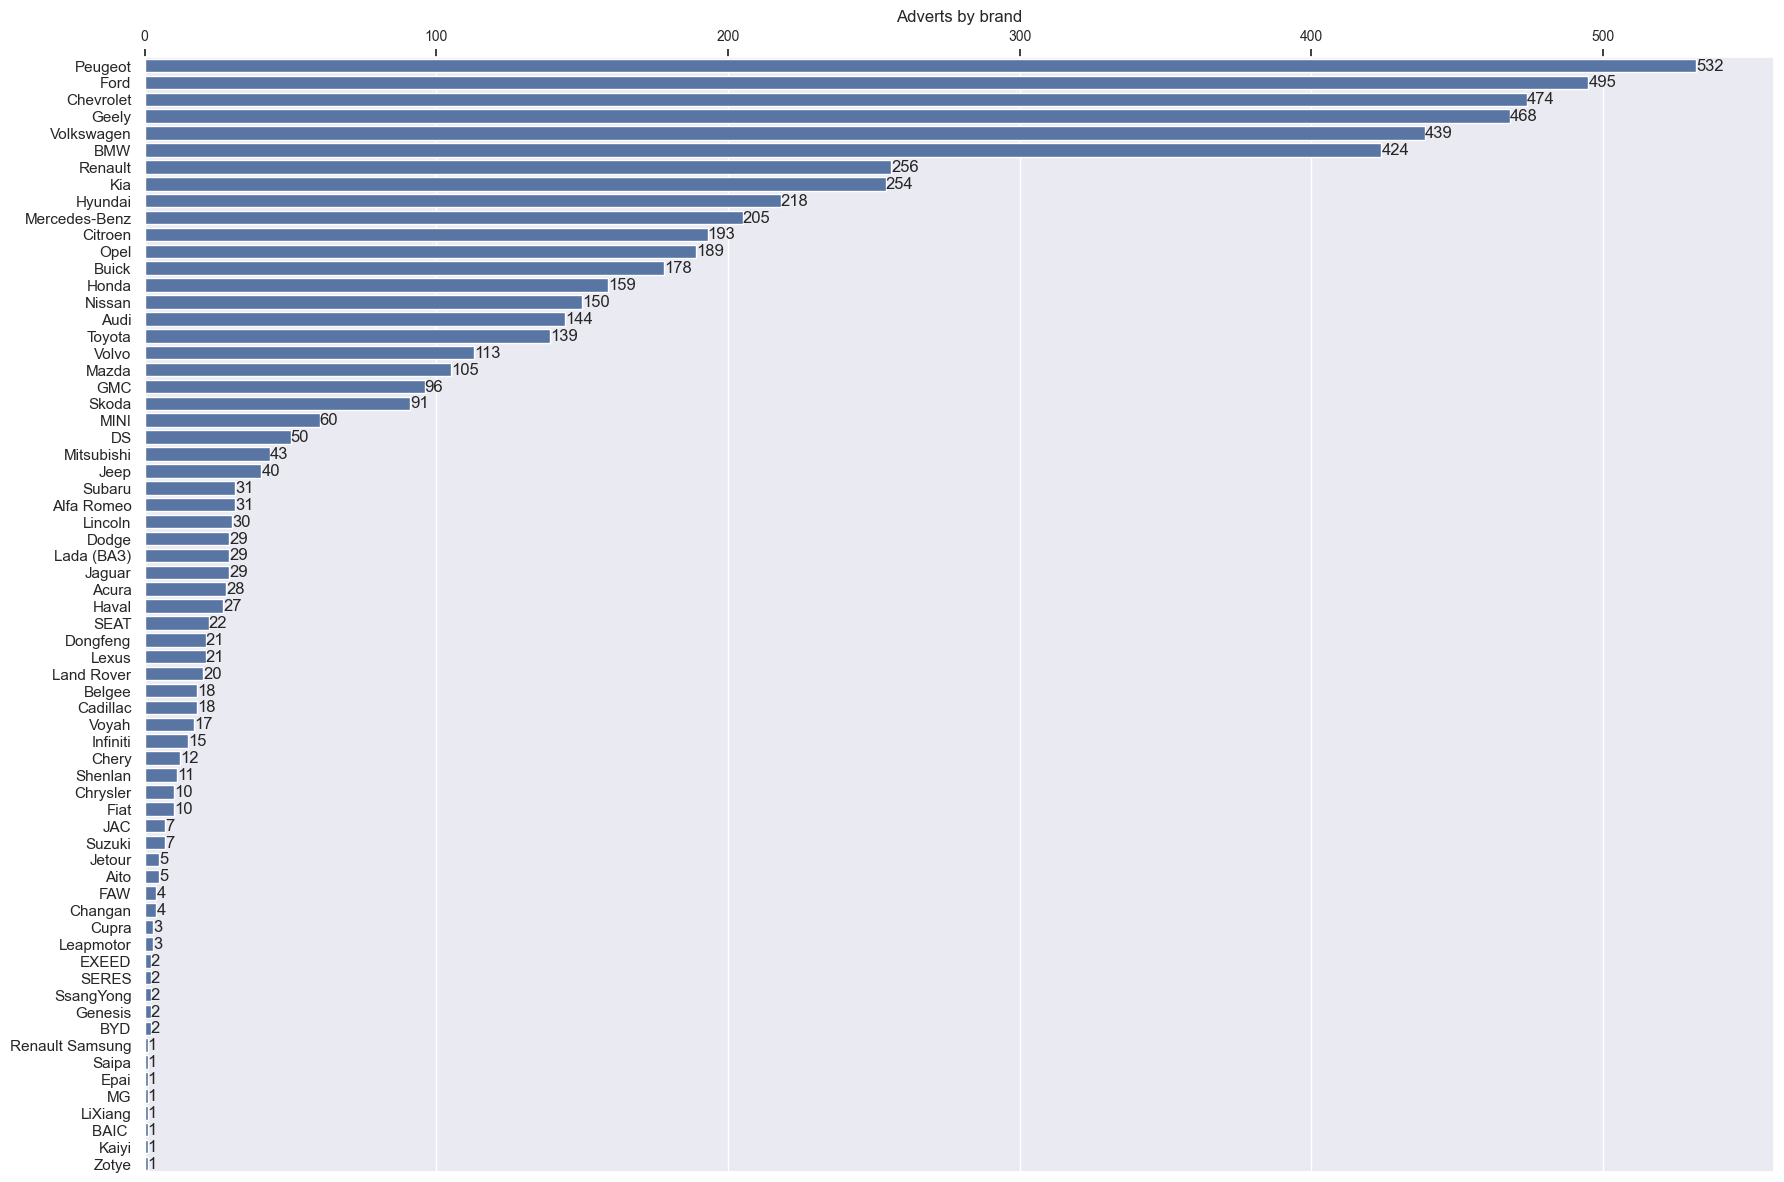

In [125]:
# Adverts by brand
f, ax = plt.subplots()

sns.barplot(
    data=df.groupby("_brand")["_brand"].count().reset_index(name="count").sort_values(by="count", ascending=False),
    x="count",
    y="_brand")

ax.set_title("Adverts by brand")
ax.bar_label(ax.containers[0])
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()

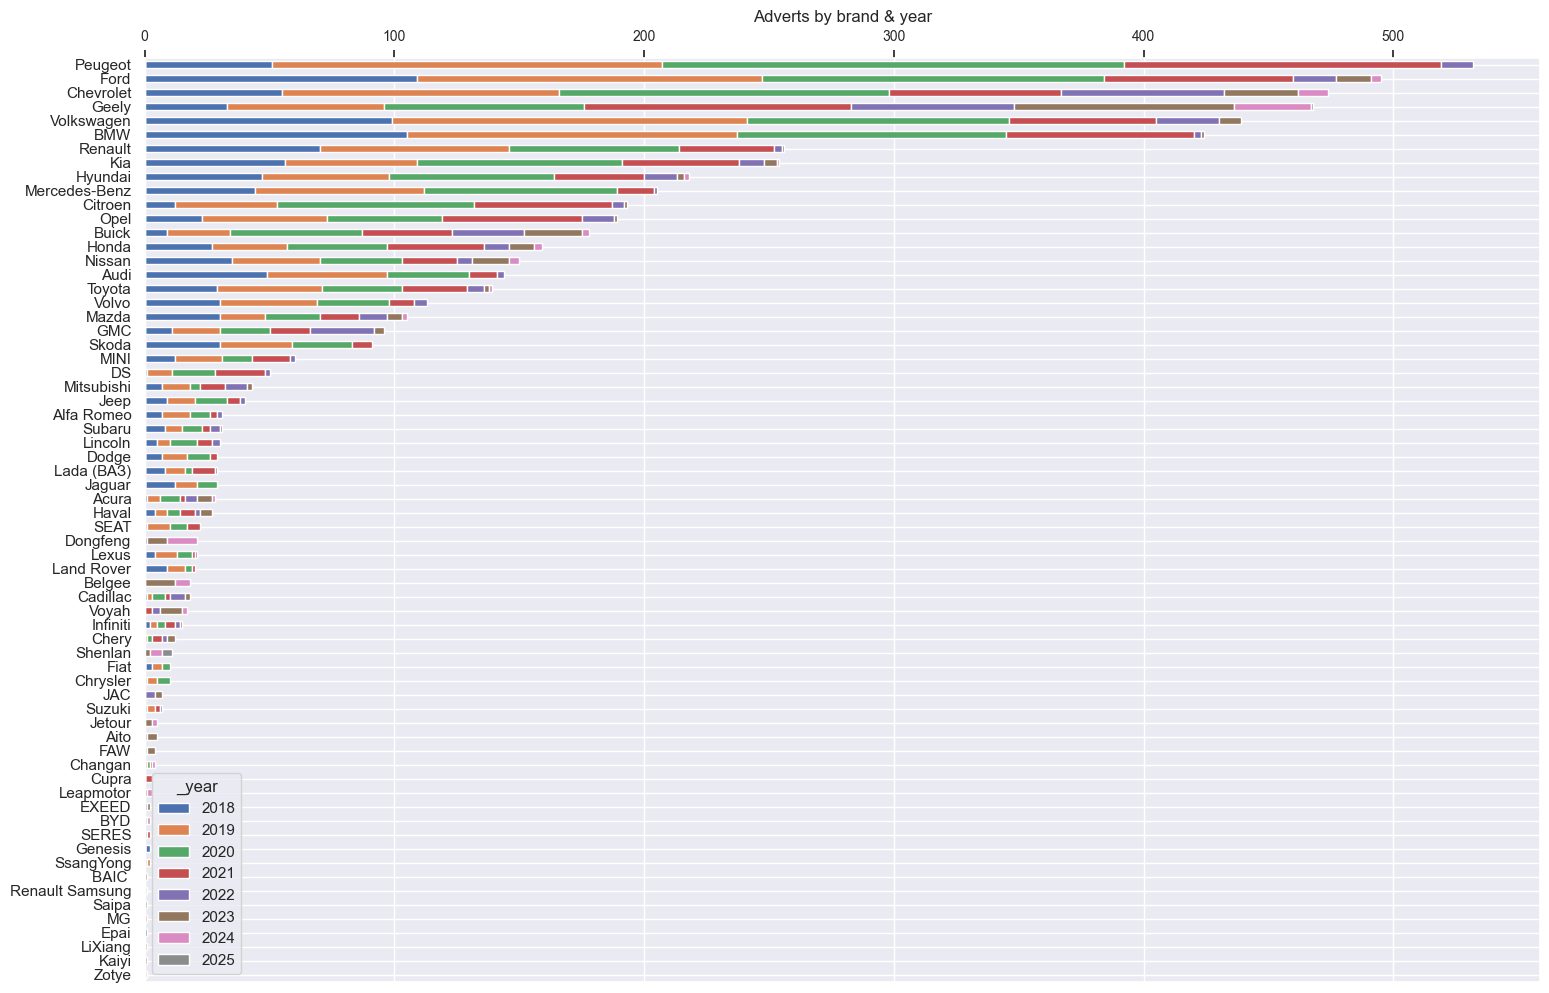

In [126]:
# Adverts by brand & year
index = df[["_brand"]].groupby(["_brand"]).size().sort_values(ascending=True)
data = df[["_brand", "_year"]].groupby(["_brand", "_year"], sort=True).size().unstack().fillna(0).reindex(index.index)
data.plot(kind="barh", stacked=True)
plt.gca().set_title("Adverts by brand & year")
plt.gca().set_xlabel(None)
plt.gca().set_ylabel(None)
plt.gca().xaxis.tick_top()
plt.show()

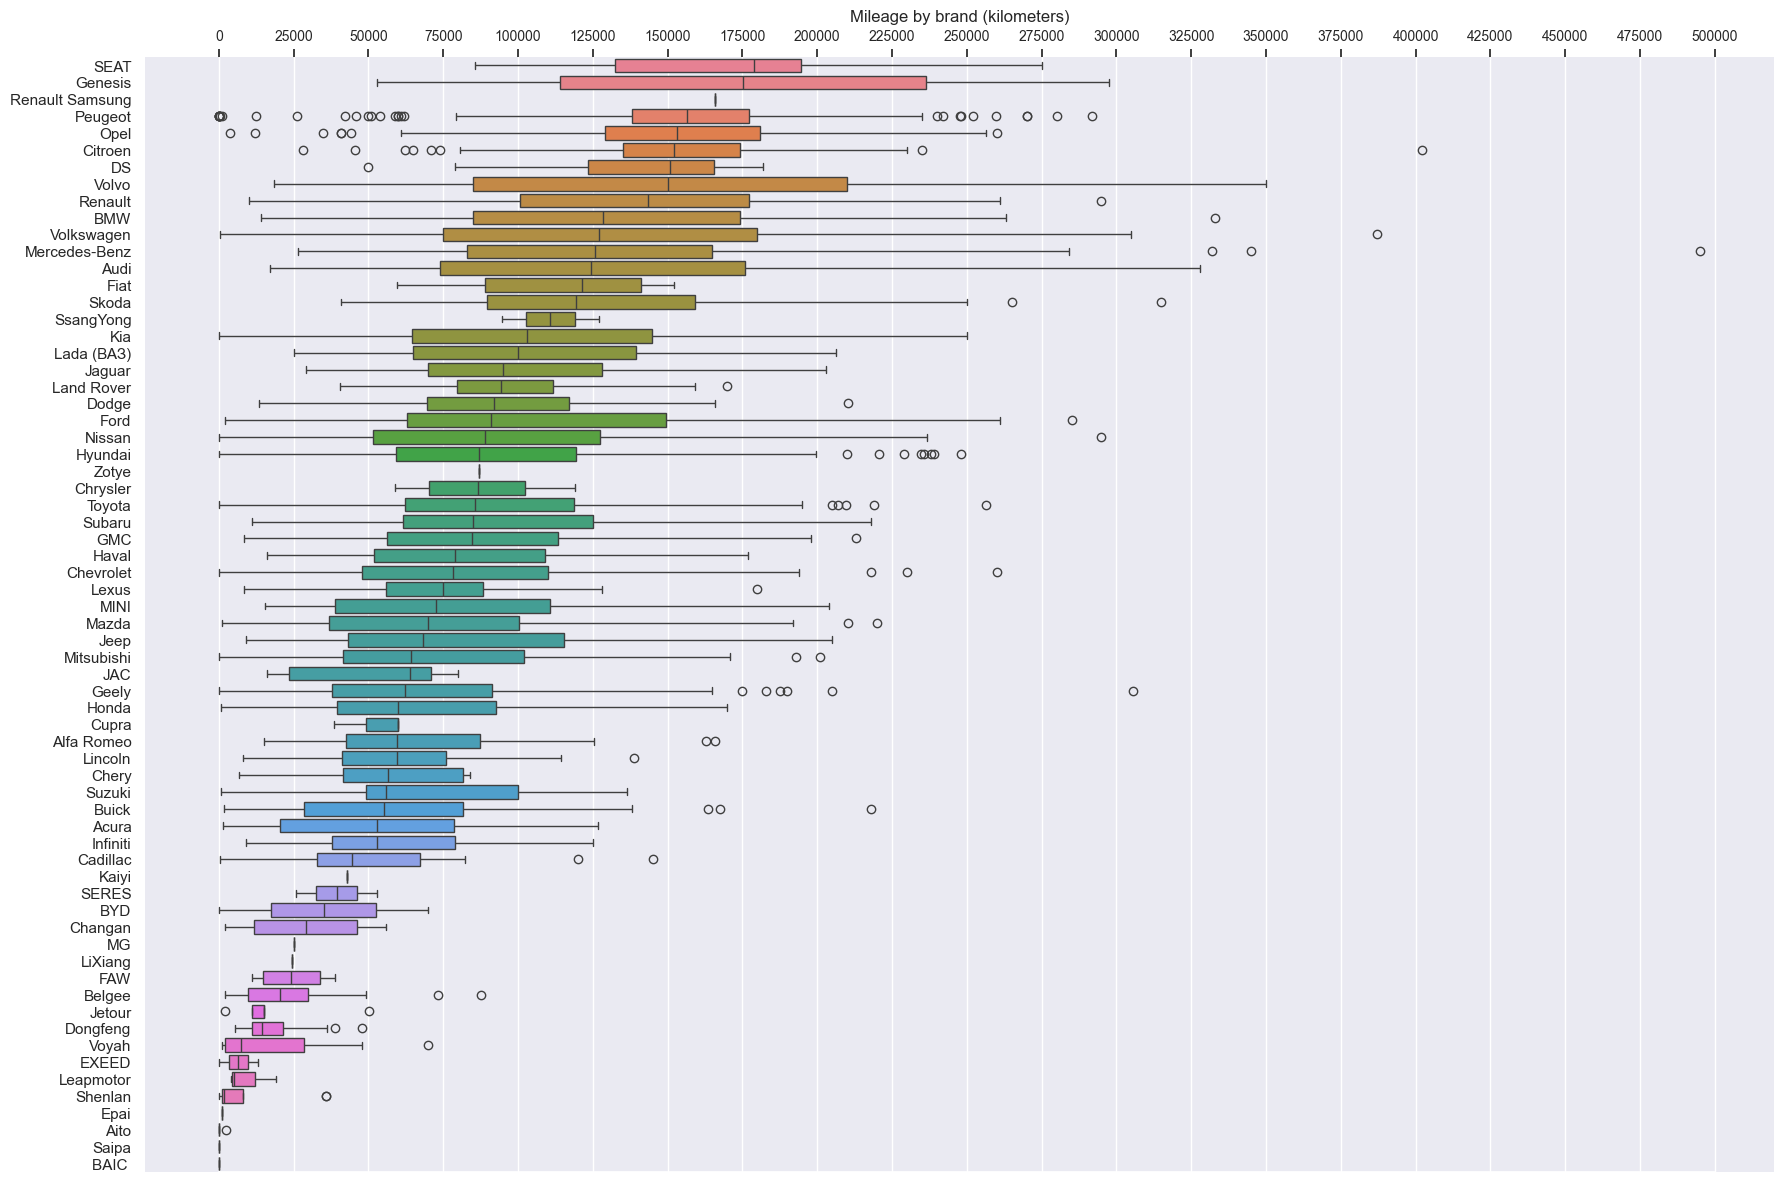

In [127]:
# Mileage by brand
f, ax = plt.subplots()

meds = df.groupby("_brand")["_mileageKm"].median().reset_index().set_index("_brand").sort_values(by="_mileageKm", ascending=False).to_dict()["_mileageKm"]
data = df[["_brand", "_mileageKm"]].reset_index(drop=True).sort_values(by=["_brand"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_mileageKm", y="_brand", hue="_brand")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Mileage by brand (kilometers)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 525000, 25000))

plt.tight_layout()
plt.show()

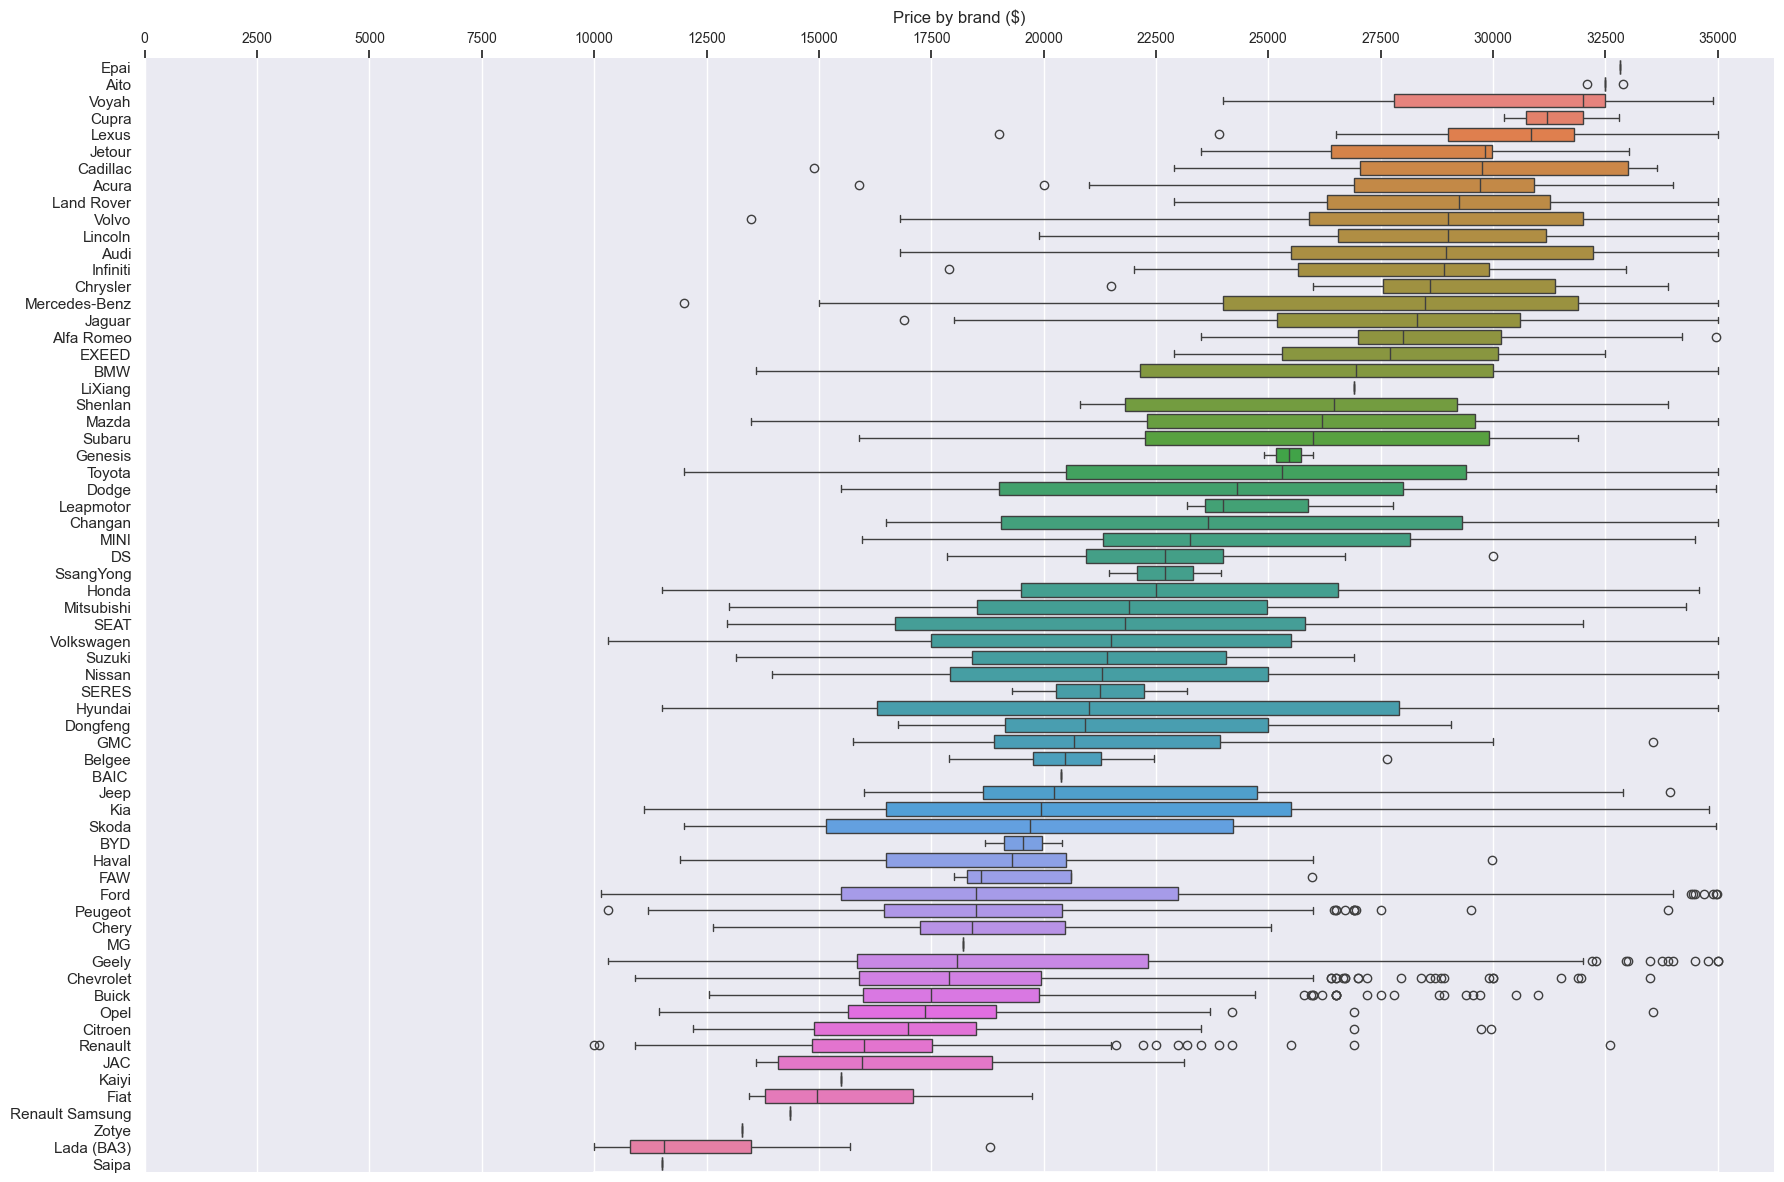

In [128]:
# Price by brand
f, ax = plt.subplots()

meds = df.groupby("_brand")["_priceUsd"].median().reset_index().set_index("_brand").sort_values(by="_priceUsd", ascending=False).to_dict()["_priceUsd"]
data = df[["_brand", "_priceUsd"]].reset_index(drop=True).sort_values(by=["_brand"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_priceUsd", y="_brand", hue="_brand")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Price by brand ($)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 37500, 2500))

plt.tight_layout()
plt.show()

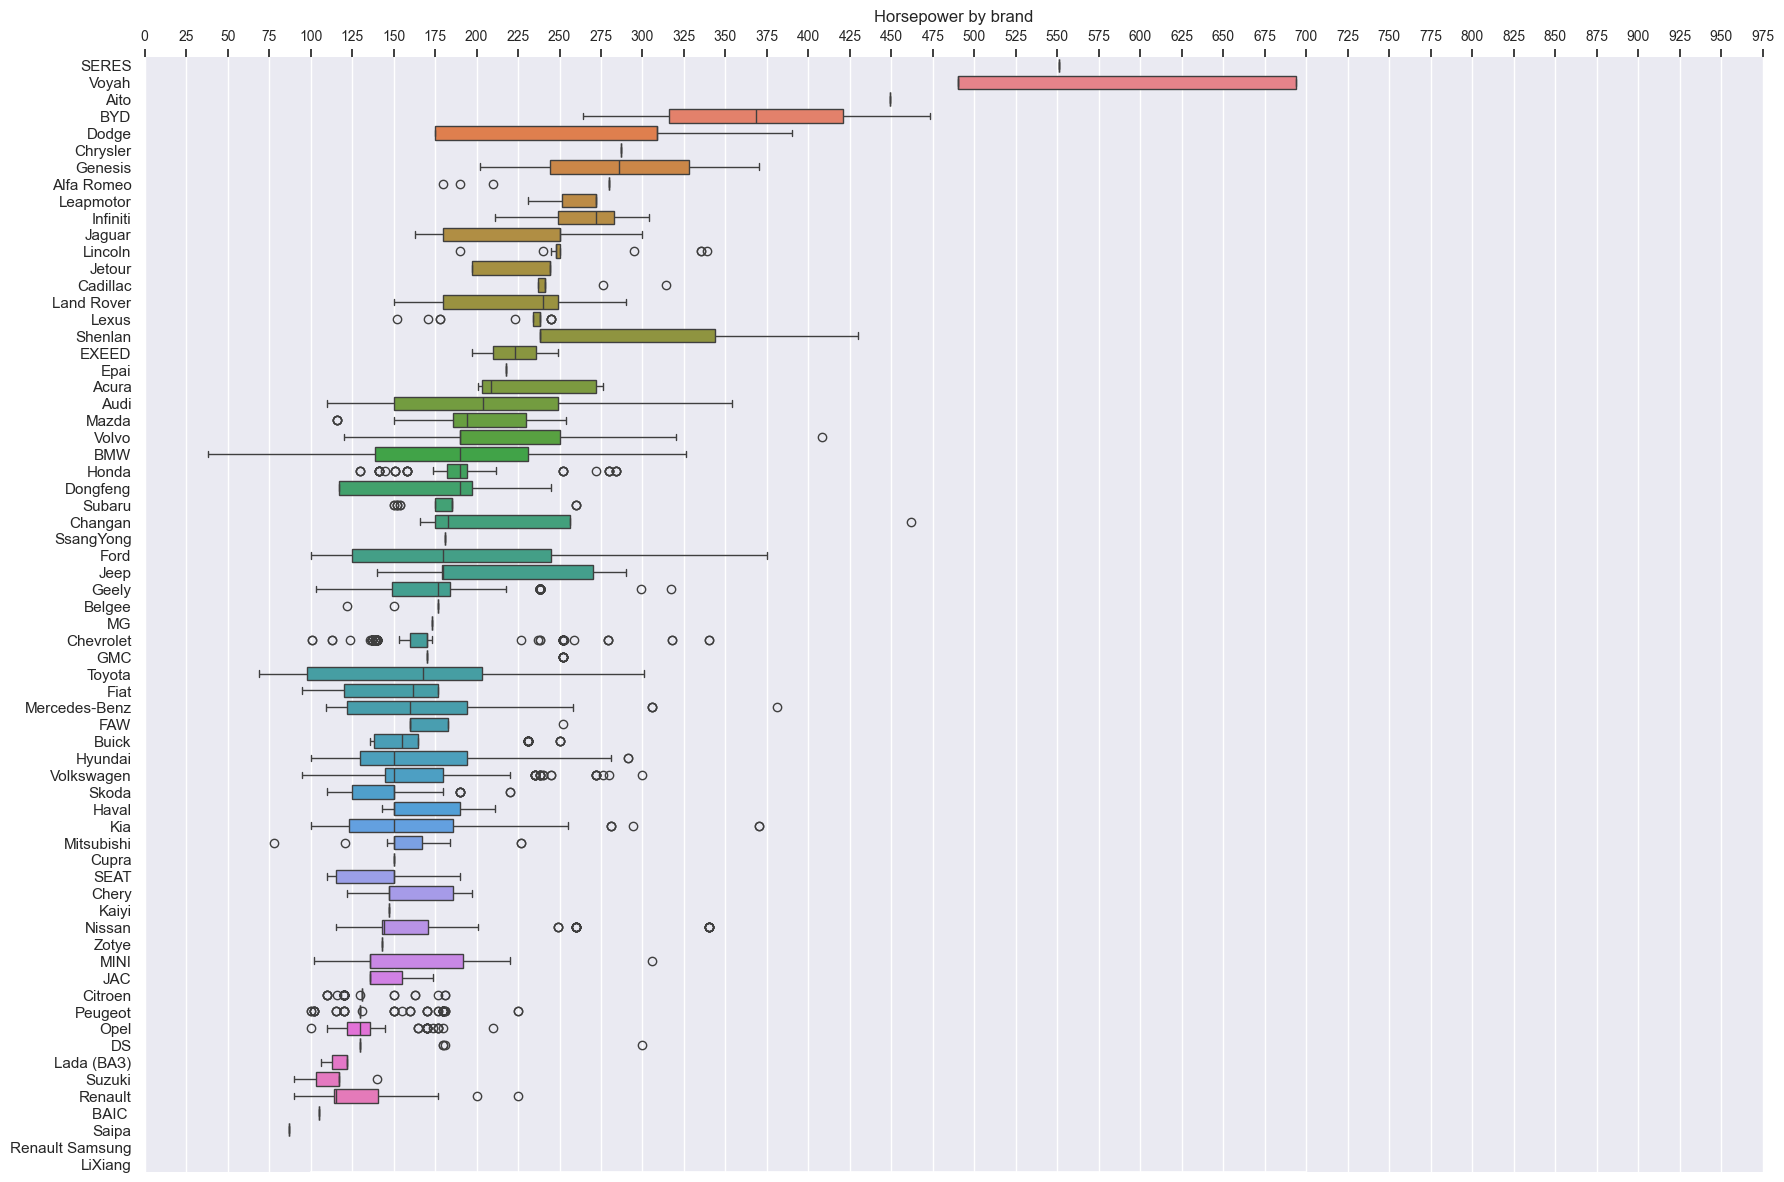

In [129]:
# Horsepower by brand
f, ax = plt.subplots()

meds = df.groupby("_brand")["_enginePower"].median().reset_index().set_index("_brand").sort_values(by="_enginePower", ascending=False).to_dict()["_enginePower"]
data = df[["_brand", "_enginePower"]].reset_index(drop=True).sort_values(by=["_brand"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_enginePower", y="_brand", hue="_brand")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Horsepower by brand")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 1000, 25))

plt.tight_layout()
plt.show()

/var/folders/_d/nphlkgzn75513vs1yff5bfs80000gn/T/ipykernel_16500/2829570466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["_advertAgeDays"] = data["_publishedAt"].apply(lambda x: (datetime.datetime.now().replace(tzinfo=None) - datetime.datetime.fromisoformat(x).replace(tzinfo=None)).days)


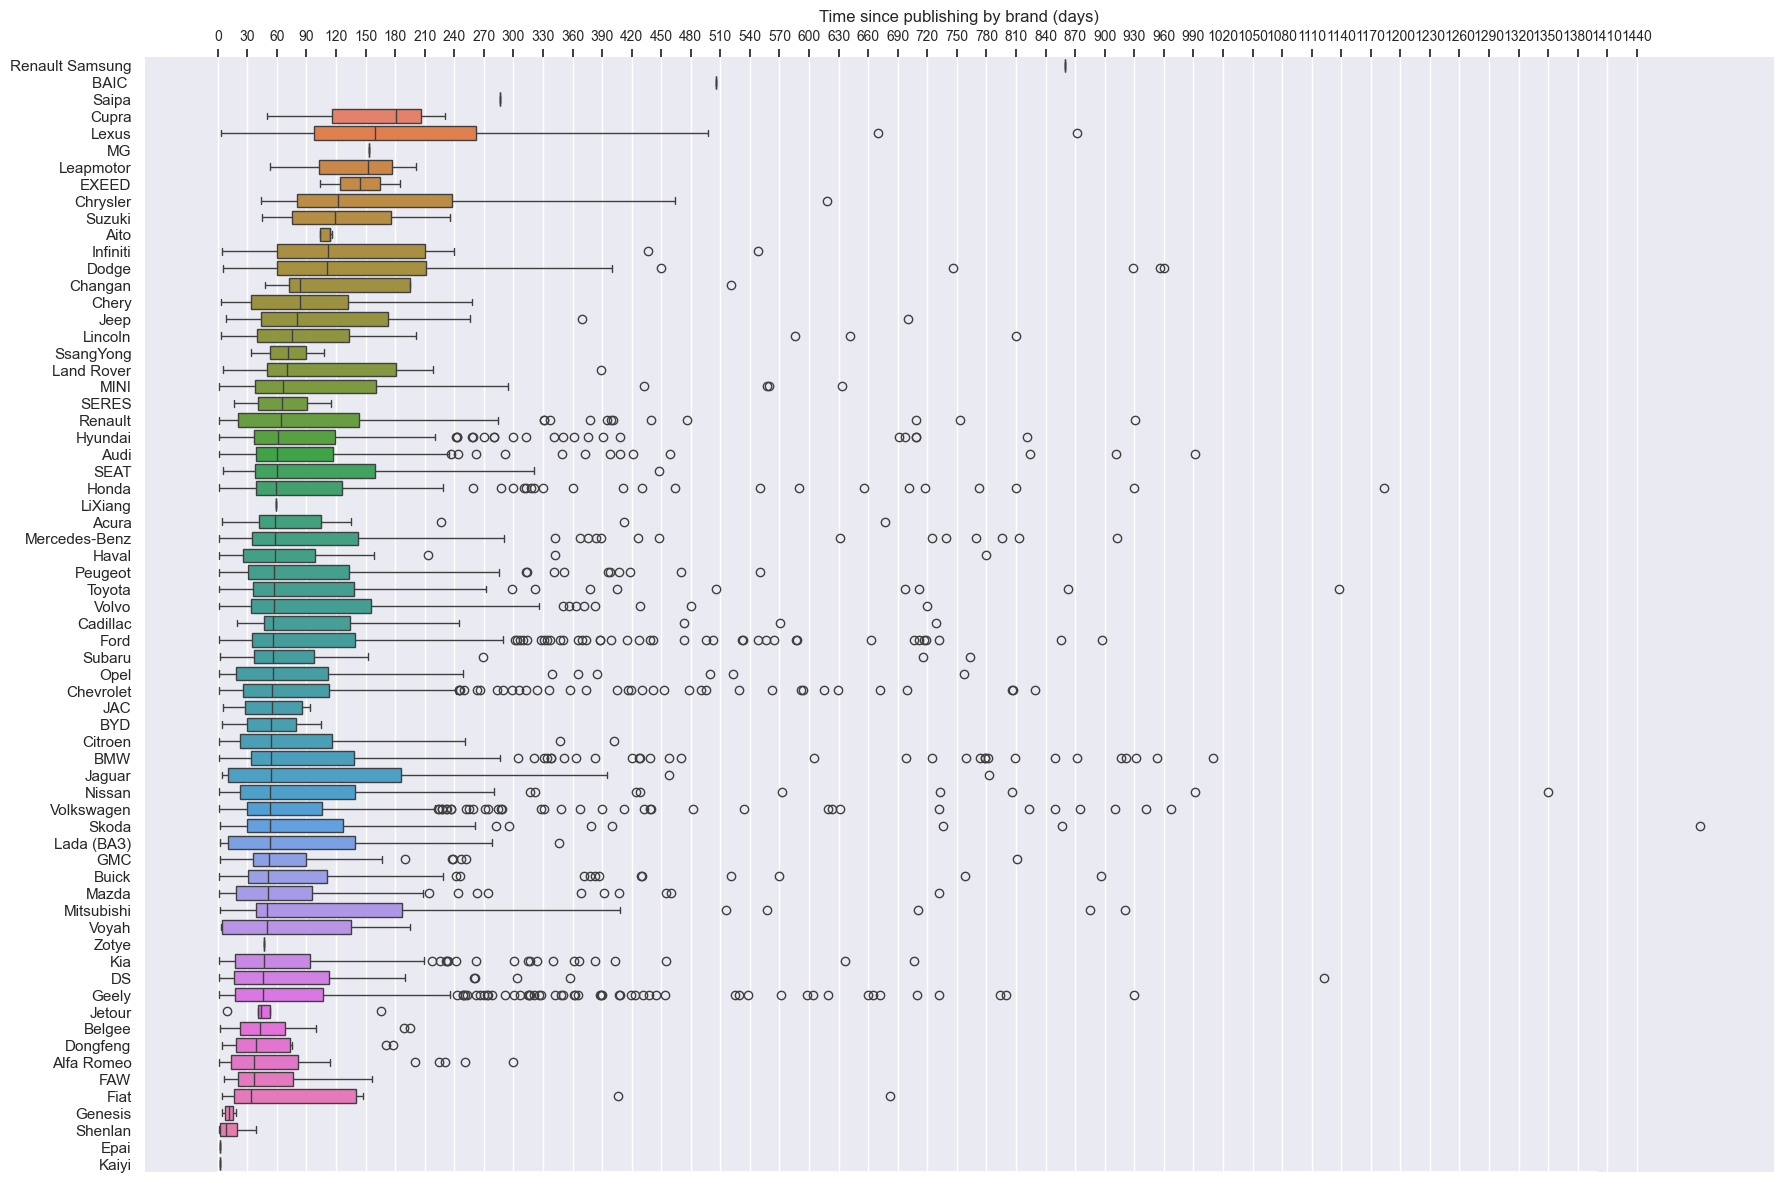

In [130]:
# Oldest adverts by brands
f, ax = plt.subplots()

data = df[["_brand", "_publishedAt"]]
data["_advertAgeDays"] = data["_publishedAt"].apply(lambda x: (datetime.datetime.now().replace(tzinfo=None) - datetime.datetime.fromisoformat(x).replace(tzinfo=None)).days)
meds = data.groupby("_brand")["_advertAgeDays"].median().reset_index().set_index("_brand").sort_values(by="_advertAgeDays", ascending=False).to_dict()["_advertAgeDays"]
data = data[["_brand", "_advertAgeDays"]].reset_index(drop=True).sort_values(by=["_brand"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_advertAgeDays", y="_brand", hue="_brand")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Time since publishing by brand (days)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 365 * 4, 30))

plt.tight_layout()
plt.show()

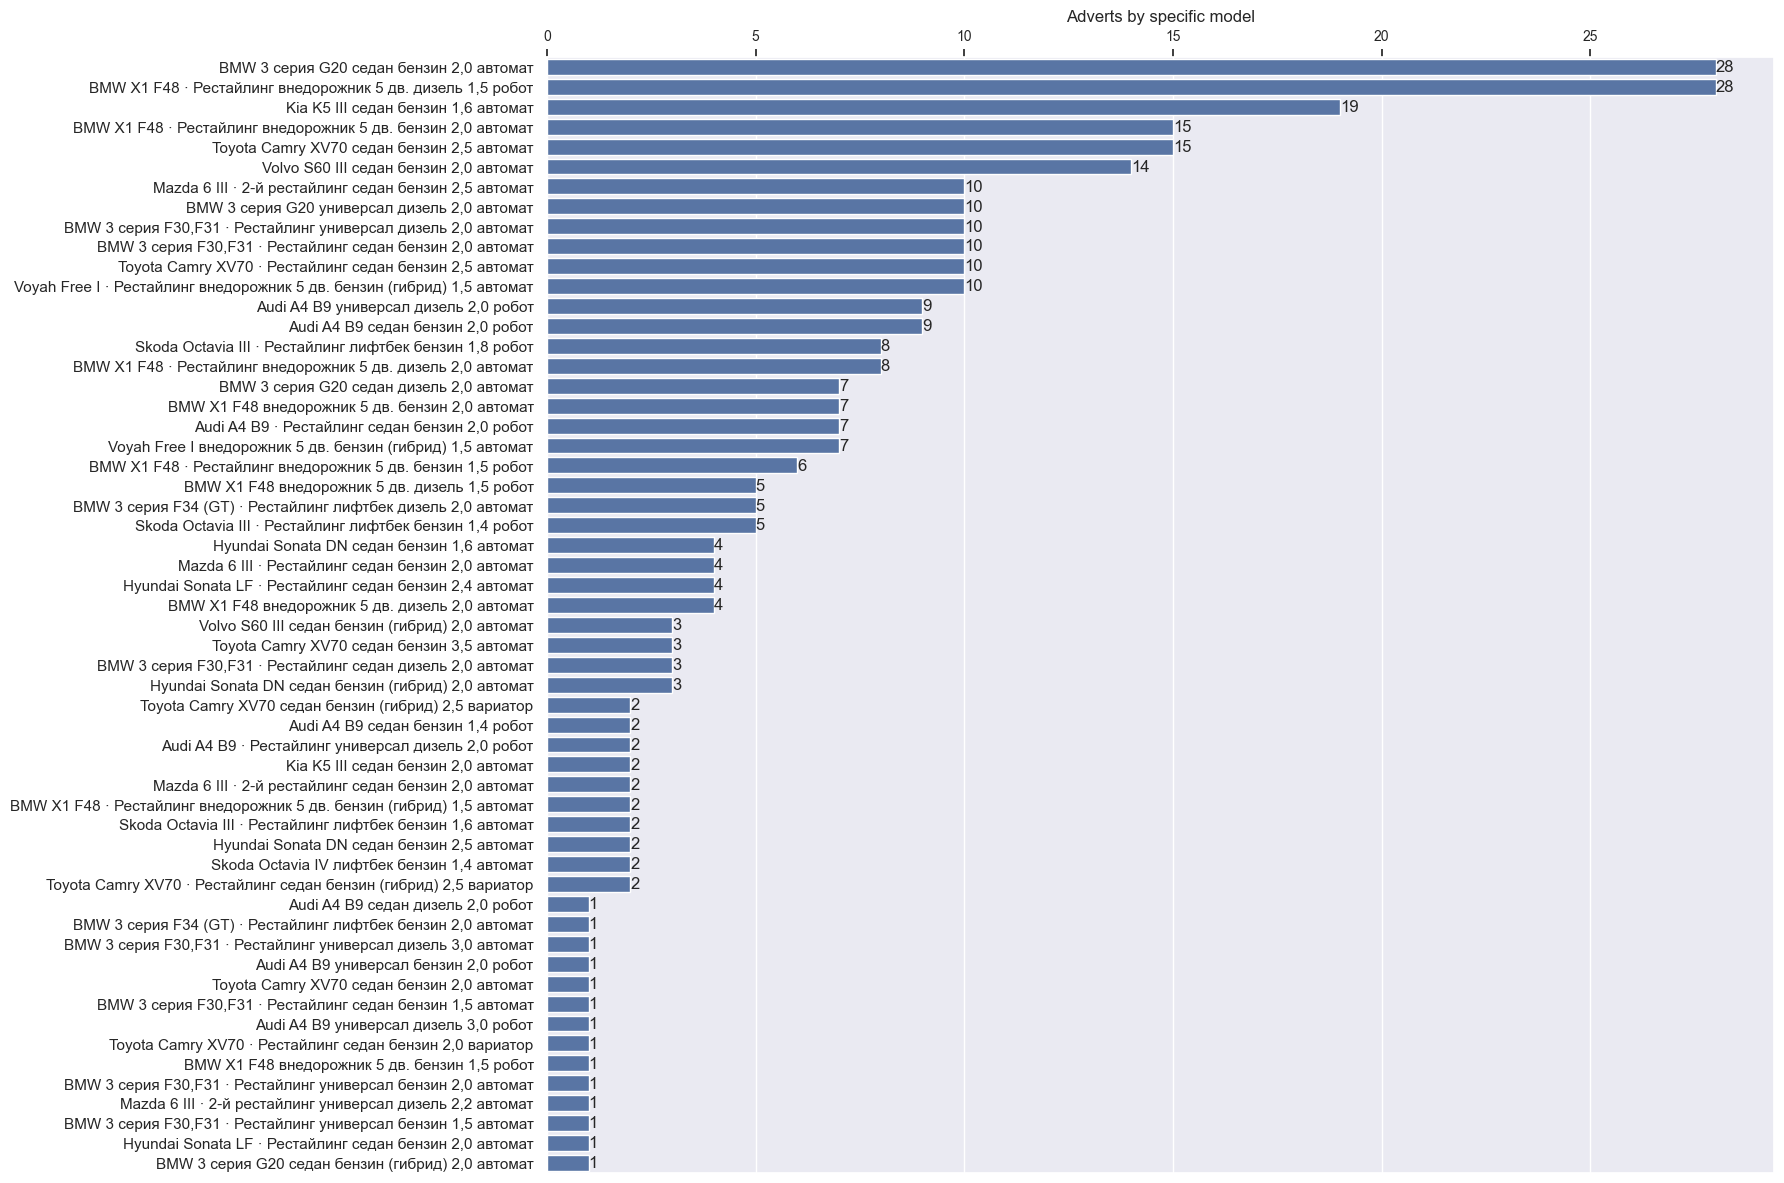

In [131]:
# Adverts by specific model
f, ax = plt.subplots()

sns.barplot(
    data=subdf.groupby("_specificModel")["_specificModel"].count().reset_index(name="count").sort_values(by="count", ascending=False),
    x="count",
    y="_specificModel")

ax.set_title("Adverts by specific model")
ax.bar_label(ax.containers[0])
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()

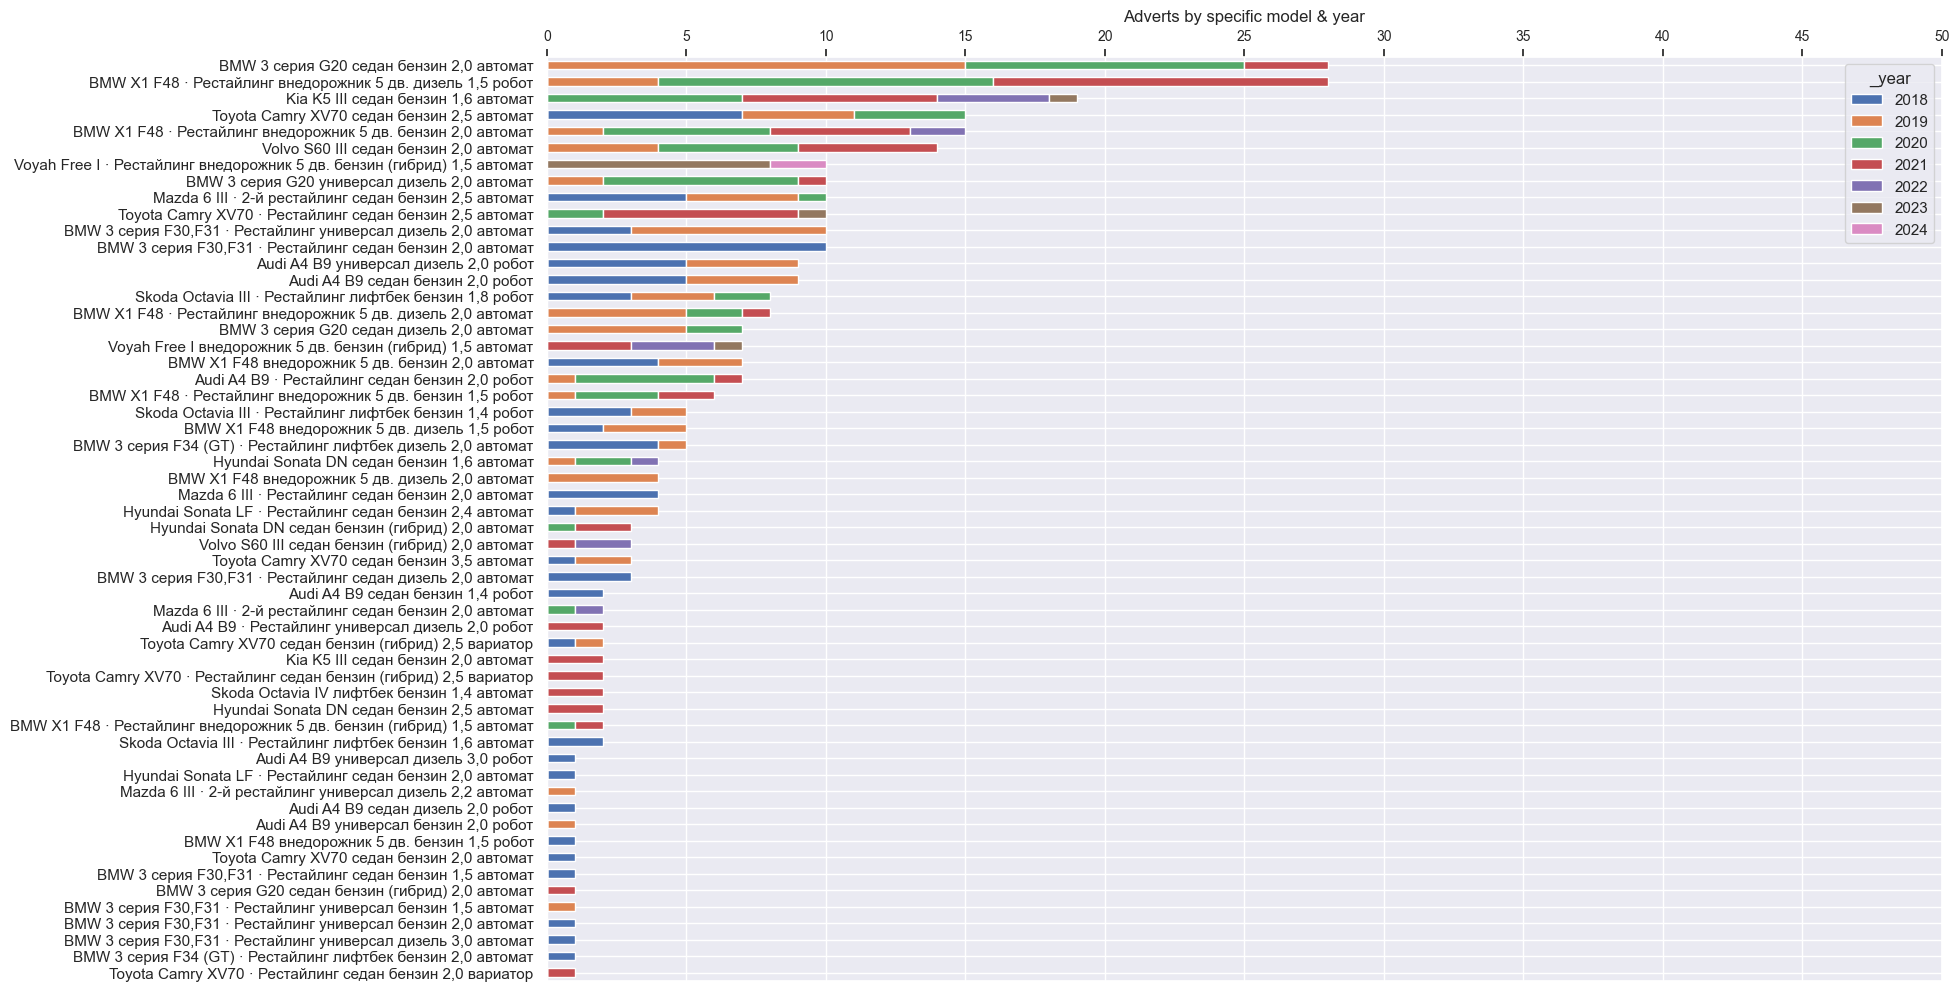

In [132]:
# Adverts by specific model & year
index = subdf[["_specificModel"]].groupby(["_specificModel"]).size().sort_values(ascending=True)
data = subdf[["_specificModel", "_year"]].groupby(["_specificModel", "_year"], sort=True).size().unstack().fillna(0).reindex(index.index)
data.plot(kind="barh", stacked=True)
plt.gca().set_title("Adverts by specific model & year")
plt.gca().set_xlabel(None)
plt.gca().set_ylabel(None)
plt.gca().set_xticks(np.arange(0, 55, 5))
plt.gca().xaxis.tick_top()
plt.show()

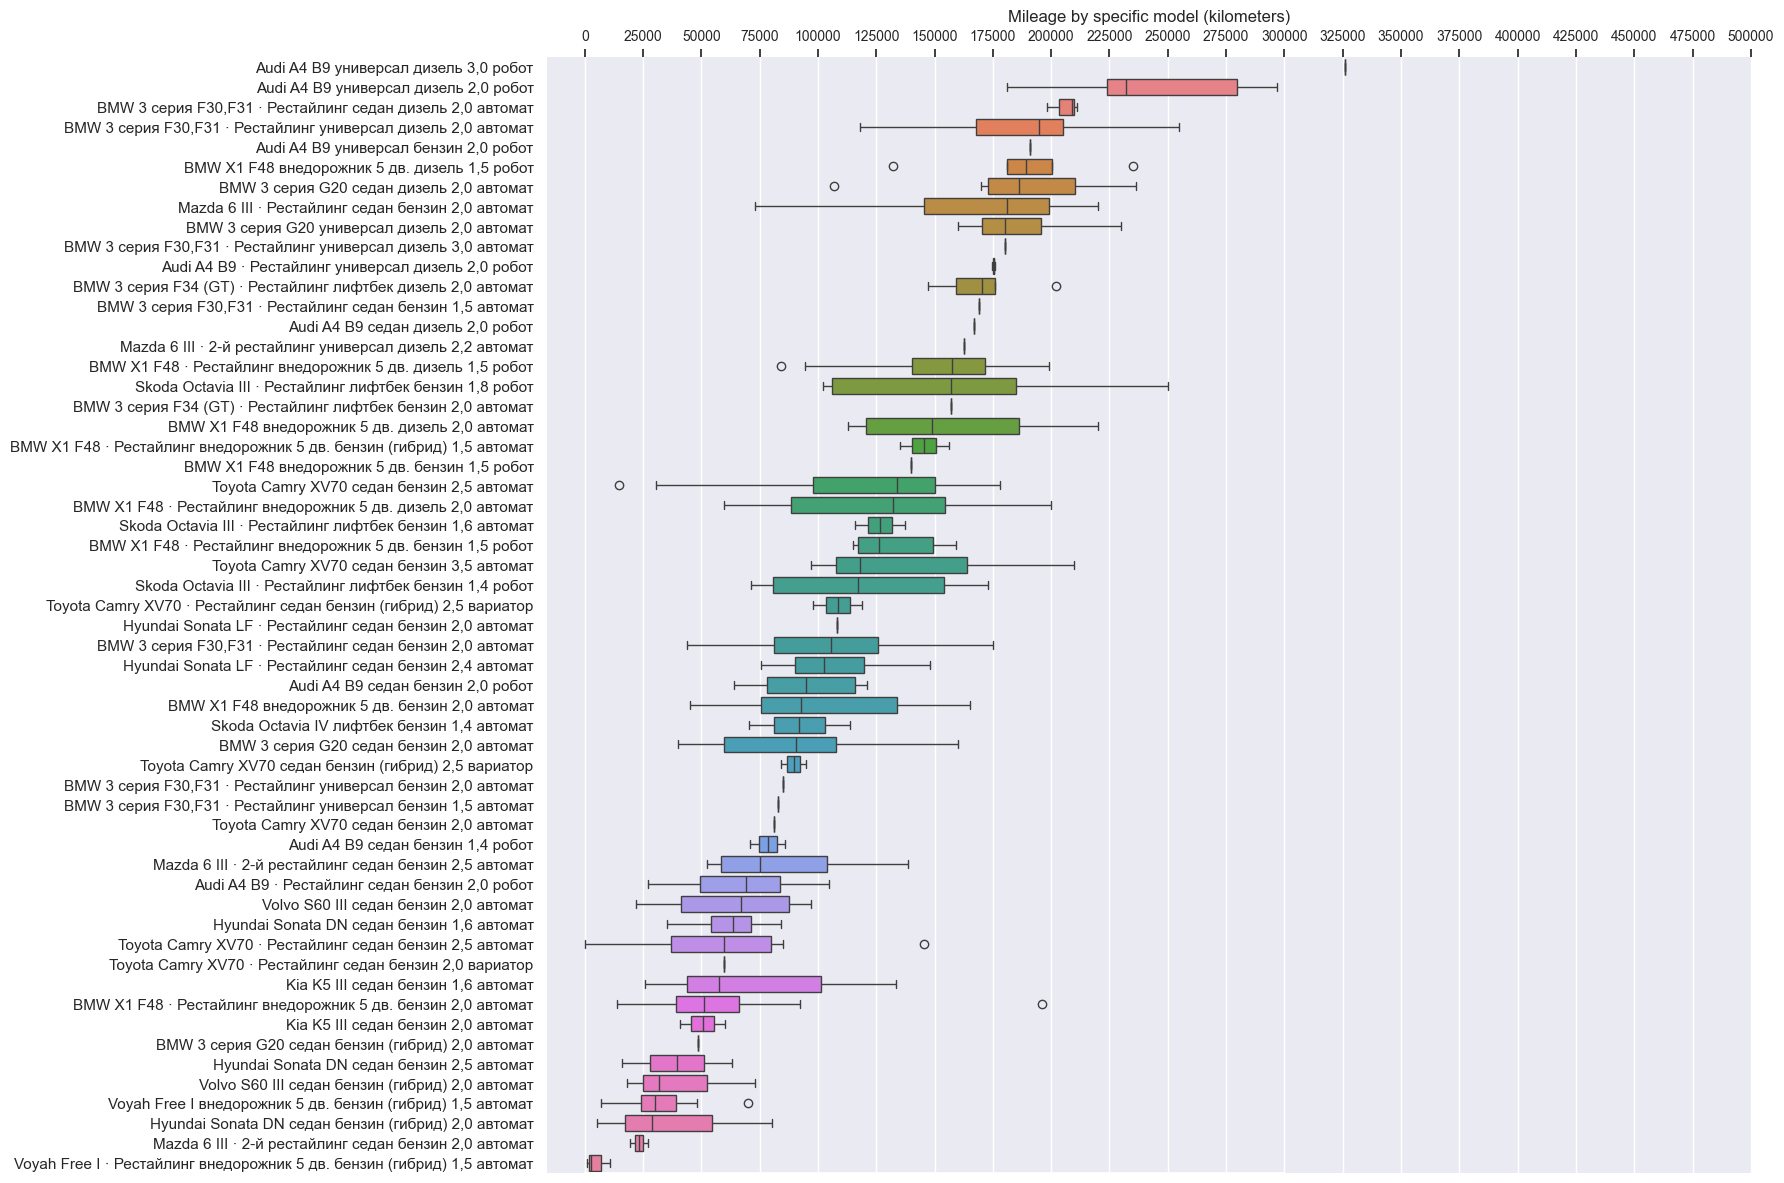

In [133]:
# Mileage by specific model
f, ax = plt.subplots()

meds = subdf.groupby("_specificModel")["_mileageKm"].median().reset_index().set_index("_specificModel").sort_values(by="_mileageKm", ascending=False).to_dict()["_mileageKm"]
data = subdf[["_specificModel", "_mileageKm"]].reset_index(drop=True).sort_values(by=["_specificModel"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_mileageKm", y="_specificModel", hue="_specificModel")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Mileage by specific model (kilometers)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 525000, 25000))

plt.tight_layout()
plt.show()

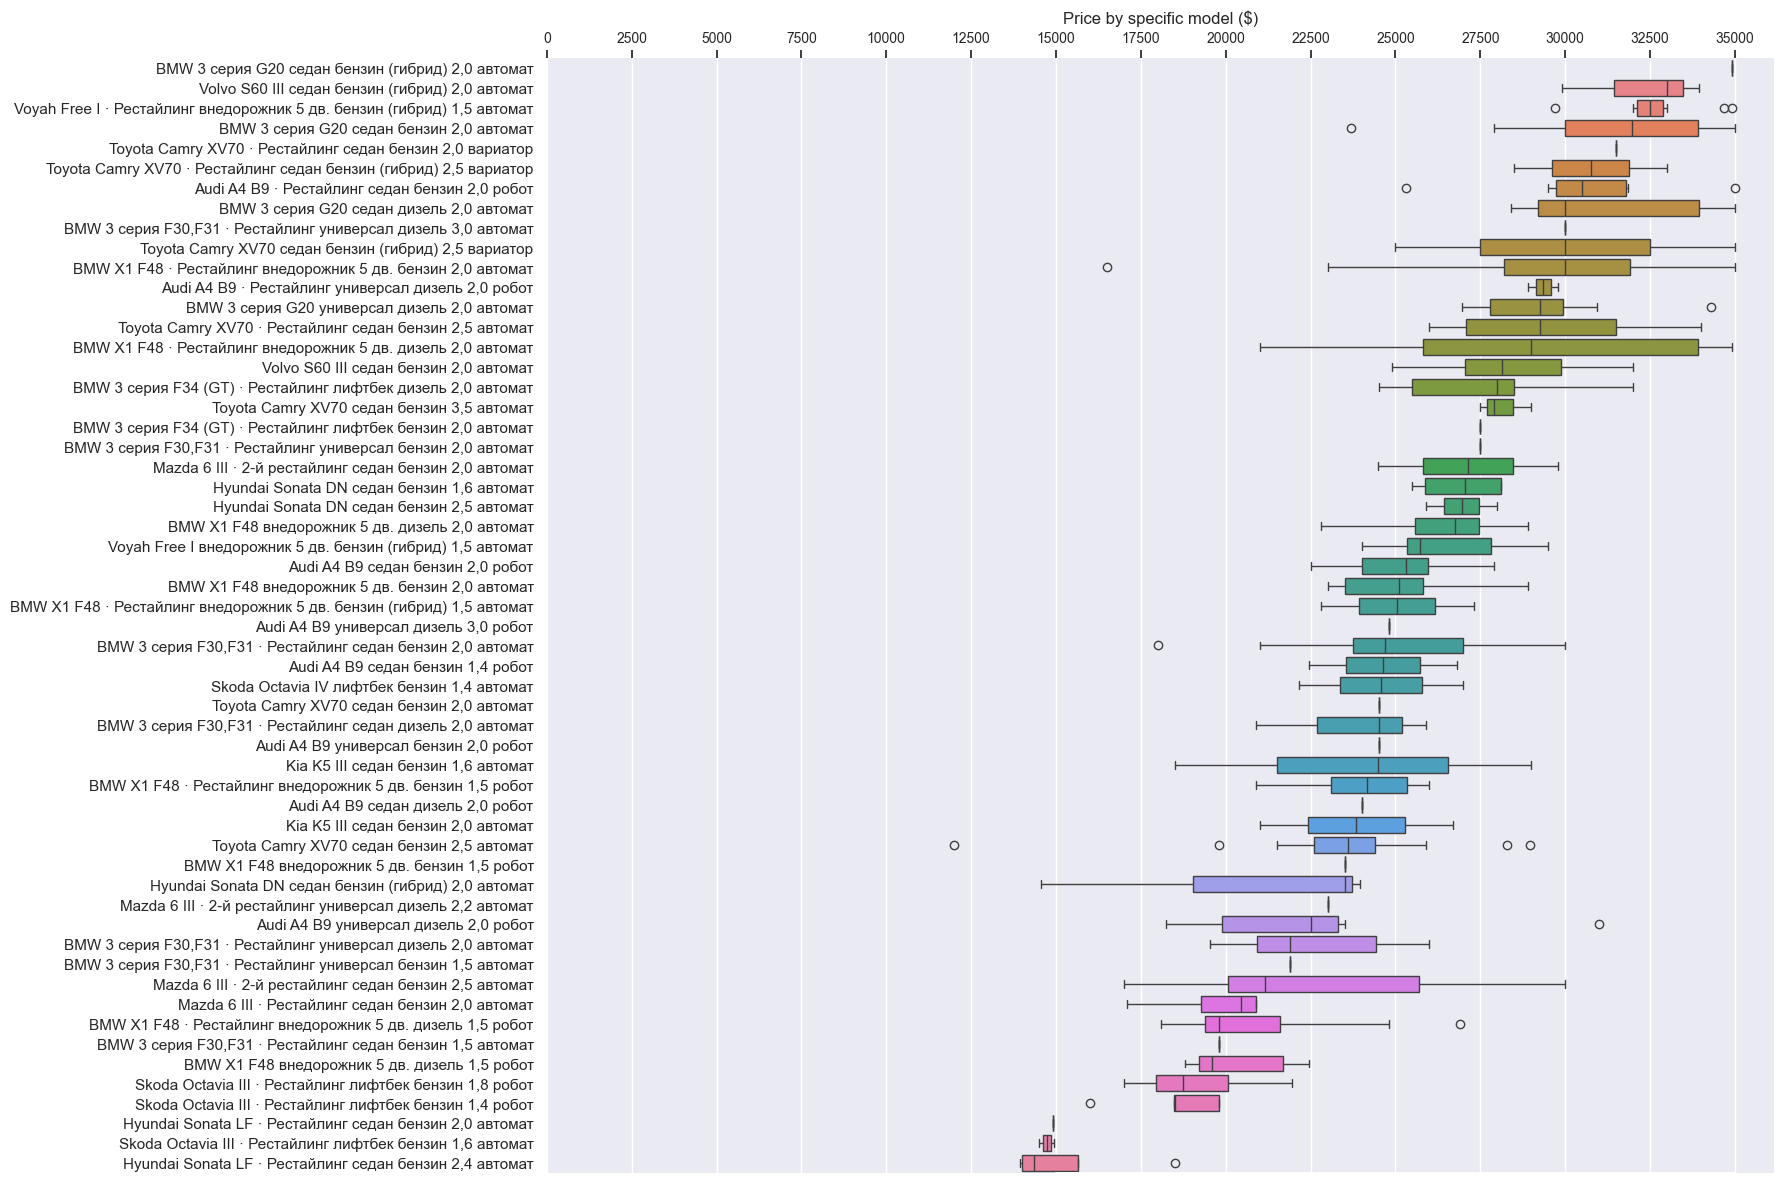

In [134]:
# Price by specific model
f, ax = plt.subplots()

meds = subdf.groupby('_specificModel')["_priceUsd"].median().reset_index().set_index('_specificModel').sort_values(by="_priceUsd", ascending=False).to_dict()["_priceUsd"]
data = subdf[['_specificModel', "_priceUsd"]].reset_index(drop=True).sort_values(by='_specificModel', key=lambda brand: brand.map(meds), ascending=False)


sns.boxplot(data=data, x="_priceUsd", y="_specificModel", hue='_specificModel')
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Price by specific model ($)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 37500, 2500))

plt.tight_layout()
plt.show()

/var/folders/_d/nphlkgzn75513vs1yff5bfs80000gn/T/ipykernel_16500/1925535005.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["_advertAgeDays"] = data["_publishedAt"].apply(lambda x: (datetime.datetime.now().replace(tzinfo=None) - datetime.datetime.fromisoformat(x).replace(tzinfo=None)).days)


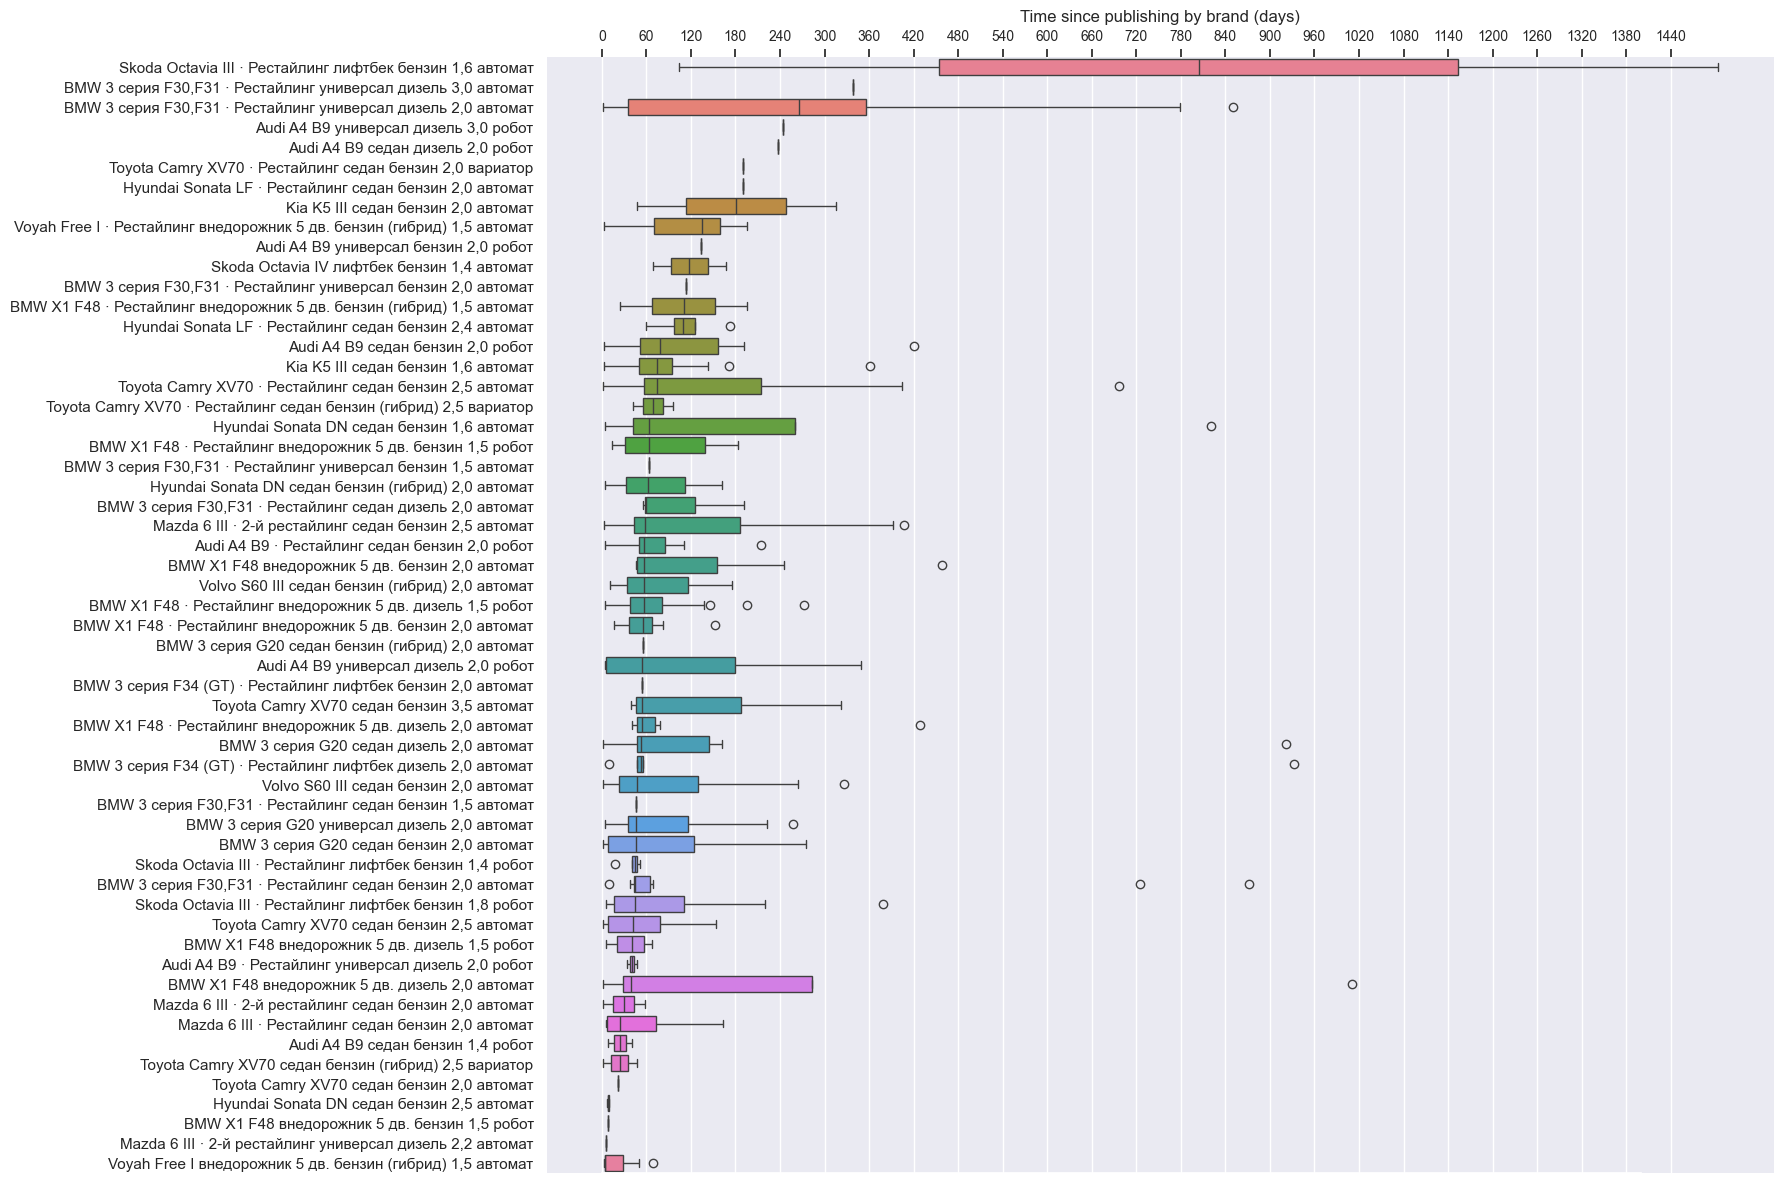

In [135]:
# Oldest adverts by brands
f, ax = plt.subplots()

data = subdf[["_specificModel", "_publishedAt"]]
data["_advertAgeDays"] = data["_publishedAt"].apply(lambda x: (datetime.datetime.now().replace(tzinfo=None) - datetime.datetime.fromisoformat(x).replace(tzinfo=None)).days)
meds = data.groupby("_specificModel")["_advertAgeDays"].median().reset_index().set_index("_specificModel").sort_values(by="_advertAgeDays", ascending=False).to_dict()["_advertAgeDays"]
data = data[["_specificModel", "_advertAgeDays"]].reset_index(drop=True).sort_values(by=["_specificModel"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_advertAgeDays", y="_specificModel", hue="_specificModel")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Time since publishing by brand (days)")
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_xticks(np.arange(0, 365 * 4, 60))

plt.tight_layout()
plt.show()

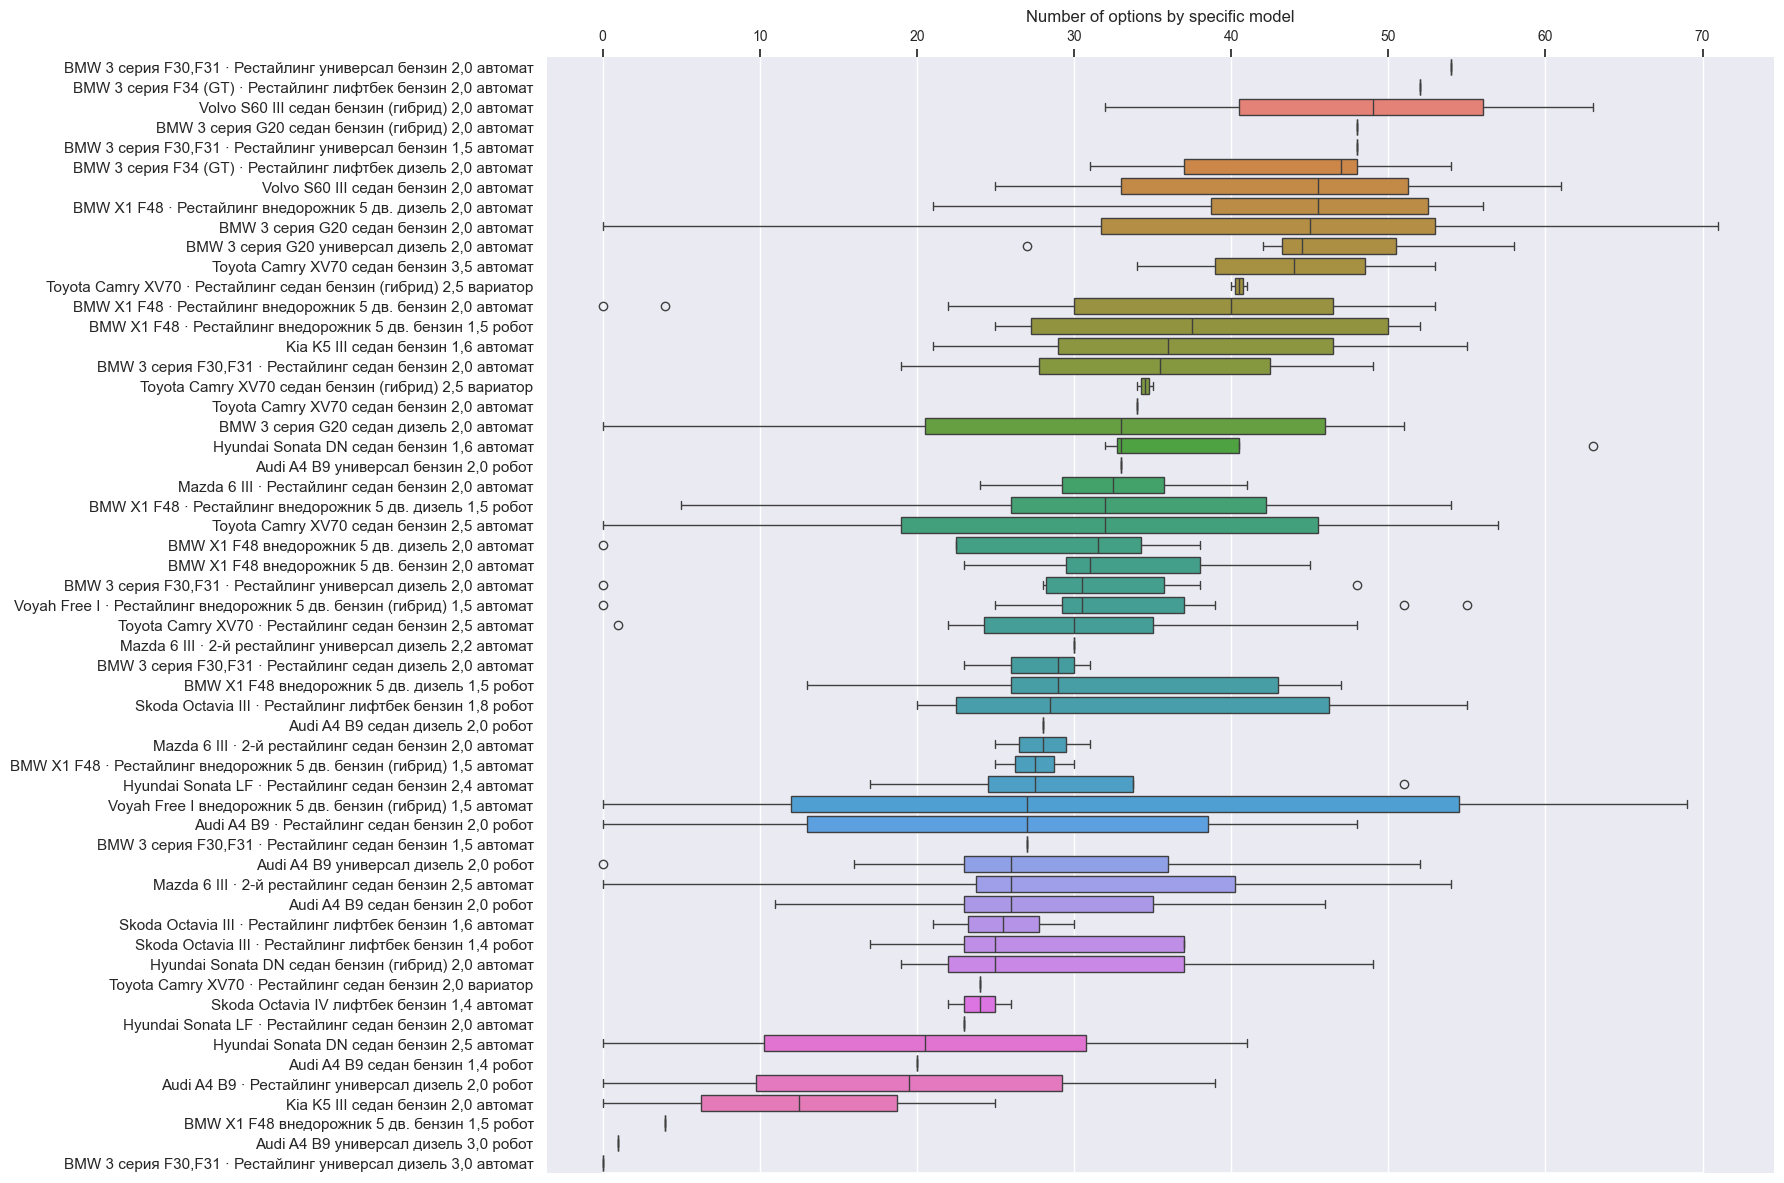

In [136]:
# Number of options by specific model
f, ax = plt.subplots()

data = subdf
data["_numberOfOptions"] = subdf.select_dtypes(bool).sum(axis=1)
meds = data.groupby("_specificModel")["_numberOfOptions"].median().reset_index().set_index("_specificModel").sort_values(by="_numberOfOptions", ascending=False).to_dict()["_numberOfOptions"]
data = data[["_specificModel", "_numberOfOptions"]].reset_index(drop=True).sort_values(by=["_specificModel"], key=lambda brand: brand.map(meds), ascending=False)

sns.boxplot(data=data, x="_numberOfOptions", y="_specificModel", hue="_specificModel")
sns.despine(trim=True, left=True)
ax.xaxis.grid(True)
ax.xaxis.tick_top()
ax.set(ylabel="")
ax.set_title("Number of options by specific model")
ax.set_xlabel(None)
ax.set_ylabel(None)

plt.tight_layout()
plt.show()